<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Tarea 1, Feature Engineering y Validación Temporal con GBM**

**Límite de entrega para ser evaluado sobre 100 puntos:** 15 de julio, 23:59 (UTC-3)

Posteriormente pueden enviar la solución de la tarea, pero cada semana de atraso reduce 10 puntos la evaluación. Es decir, del 16 de julio 00:00 al 23 de julio 23:59 (UTC-3) se evaluará sobre 90 puntos, y así sucesivamente hasta el final de la materia.

La tarea se realiza utilizando la serie mensual AirPassengers (pasajeros de aerolíneas).

**Parte 1) Feature engineering, 20 puntos**


A partir de la serie "y", deben construir:
* Features de calendario: mes, trimestre, anio, dia_anio, y sus versiones cíclicas (sin/cos) para mes y dia_anio.
* Features con lags [1, 2, 3, 12].
* Features de ventana móvil (rolling) de tamaño 3 y 12: media, desvío, máximo y mínimo, todas con .shift(1) para no filtrar el valor actual.
* Features expansivas (expanding): media y desvío acumulados hasta el período anterior.


**Parte 2) Dos conjuntos de features, 5 puntos**


Deben armar dos grupos:
* features_fecha: solo variables de calendario.
* features_all: calendario + lags + rolling + expanding.

**Parte 3) Dos formas de particionar train/test, 5 puntos**

* Holdout temporal: los últimos 24 meses como test, todo lo anterior como train (respetando el orden cronológico).
* Holdout con shuffle: mismo tamaño de test, pero mezclando filas al azar (train_test_split(shuffle=True)).

**Parte 4) Entrenamiento de Gradient Boosting Regressor, 20 puntos**



Deben entrenar un GradientBoostingRegressor para cada combinación (2 conjuntos de features × 2 tipos de holdout = 4 modelos).

*Usar GradientBoostingRegressor para este ejercicio, no HistGradientBoostingRegressor. Este último está optimizado para datasets grandes.*

**Parte 5) Métricas, 10 puntos**



Para cada uno de los 4 modelos, calcular MAE, RMSE, MAPE y MASE (usando como referencia el naive estacional de lag 12, es decir, comparar contra "el mismo mes del año anterior").

**Parte 6) Interpretabilidad, 20 puntos**


Usando el modelo entrenado con features_all en el holdout temporal (el válido, no el de shuffle):

* Calcular la importancia nativa del modelo (feature_importances_) y graficar el top 10.
* Calcular permutation importance sobre el conjunto de test, con scoring="neg_mean_absolute_error" y al menos 30 repeticiones (n_repeats=30), y grafiquen el top 10.
* Comparar ambos rankings.

**Parte 7) Preguntas de análisis, 20 puntos**

* ¿Cuál de los dos holdouts refleja mejor el escenario real de uso del modelo (predecir el futuro)? Argumentar en términos de "el cuándo" vs "el qué pasó".
* En el holdout temporal, comparar features_fecha vs features_all. ¿Cuánto aporta realmente tener lags/rolling frente a usar solo variables de calendario?
* Interpretar el valor de MASE en el holdout temporal: ¿el modelo le gana o le pierde al naive estacional? ¿Qué les dice esto sobre la dificultad de mejorar un baseline fuerte en series cortas y muy estacionales?
* ¿Qué feature domina el ranking en ambas técnicas? ¿Por qué tiene sentido que sea esa, dada la naturaleza estacional de la serie?


**Entregable: notebook con el código corriendo y las respuestas a las 4 preguntas.**

**Link de entrega: [https://forms.gle/AJLpFTwypFJvjYETA](https://forms.gle/AJLpFTwypFJvjYETA)**

In [32]:
from statsmodels.datasets import get_rdataset

data = get_rdataset("AirPassengers").data
y = data["value"].values

In [33]:
print(y)

[112 118 132 129 121 135 148 148 136 119 104 118 115 126 141 135 125 149
 170 170 158 133 114 140 145 150 178 163 172 178 199 199 184 162 146 166
 171 180 193 181 183 218 230 242 209 191 172 194 196 196 236 235 229 243
 264 272 237 211 180 201 204 188 235 227 234 264 302 293 259 229 203 229
 242 233 267 269 270 315 364 347 312 274 237 278 284 277 317 313 318 374
 413 405 355 306 271 306 315 301 356 348 355 422 465 467 404 347 305 336
 340 318 362 348 363 435 491 505 404 359 310 337 360 342 406 396 420 472
 548 559 463 407 362 405 417 391 419 461 472 535 622 606 508 461 390 432]


### **Parte 0) Preparación de la serie**

AirPassengers es mensual (ene-1949 a dic-1960). Necesitamos un DatetimeIndex para poder derivar features de calendario con .index.month, .index.quarter, etc.


_Clase 1 "Conversión a Problema Supervisado" — sección B) AirPassengers (gráfico de la serie)_\
_Clase 2 "Ejercicio Feature Engineering" — armado del DataFrame con índice de fechas_

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fechas = pd.date_range("1949-01-01", periods=len(y), freq="MS")  # MS = inicio de mes
df = pd.DataFrame({"y": np.asarray(y, dtype=float)}, index=fechas)

print("Observaciones:", len(df), "|", df.index.min().date(), "a", df.index.max().date())
print(df.head())

Observaciones: 144 | 1949-01-01 a 1960-12-01
                y
1949-01-01  112.0
1949-02-01  118.0
1949-03-01  132.0
1949-04-01  129.0
1949-05-01  121.0


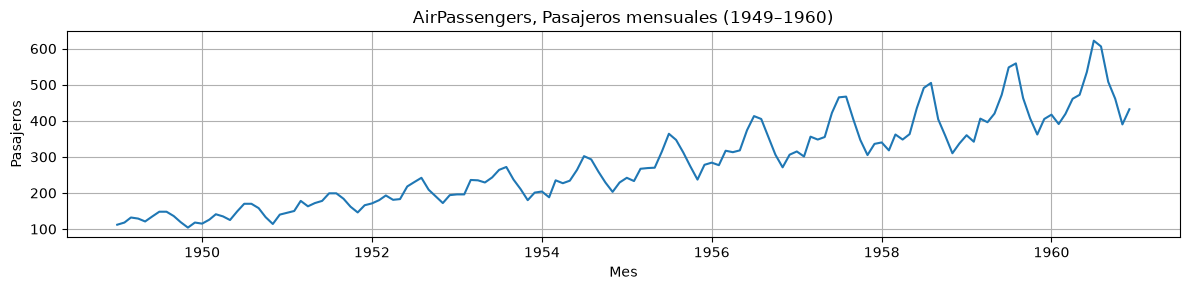

In [35]:
plt.figure(figsize=(12, 3))
plt.plot(df.index, df["y"])
plt.title("AirPassengers, Pasajeros mensuales (1949–1960)")
plt.xlabel("Mes")
plt.ylabel("Pasajeros")
plt.grid(True)
plt.tight_layout()
plt.show()

### **Parte 1) Feature engineering**

Preparación de características.

_Clase 2 "Feature Engineering"_
- _Sección B) Calendar Features ("el cuándo") y Clase 2, "Ejercicio Feature Engineering" — features de calendario_\
- _Sección D) Encoding cíclico y Clase 2, "Ejercicio Feature Engineering" — mes_sin/mes_cos, doy_sin/doy_cos._ 
Lags ("el qué pasó") y Clase 2, "Ejercicio Feature Engineering" — loop sobre la lista de lags.
- _Sección E) Rolling y Clase 2, "Ejercicio Feature Engineering" — loop for w in [...]_
- _Sección F) Expanding y Clase 2, "Ejercicio Feature Engineering" — exp_mean / exp_std_

El sin/cos hace que diciembre (12) y enero (1) queden "pegados" en el círculo, en lugar de verse lejanos como enteros.

In [36]:
df["mes"] = df.index.month           # número de mes (1..12)
df["trimestre"] = df.index.quarter   # trimestre (1..4)
df["anio"] = df.index.year           # año
df["dia_anio"] = df.index.dayofyear  # día del año del 1ro de cada mes (serie mensual)

In [37]:
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
dias_en_anio = 365.25
df["doy_sin"] = np.sin(2 * np.pi * df["dia_anio"] / dias_en_anio)
df["doy_cos"] = np.cos(2 * np.pi * df["dia_anio"] / dias_en_anio)

In [38]:
# lag_12 = "el mismo mes del año anterior": la señal estacional pura en una serie mensual.
LAGS = [1, 2, 3, 12]
for k in LAGS:
    df[f"lag_{k}"] = df["y"].shift(k)

In [39]:
# Clase 1 "Leakage Temporal" — B) Leakage por Engineered Features (media centrada vs trailing).
VENTANAS = [3, 12]
for w in VENTANAS:
    df[f"roll_mean_{w}"] = df["y"].rolling(w).mean().shift(1)  # nivel local
    df[f"roll_std_{w}"] = df["y"].rolling(w).std().shift(1)    # volatilidad local
    df[f"roll_max_{w}"] = df["y"].rolling(w).max().shift(1)    # techo reciente
    df[f"roll_min_{w}"] = df["y"].rolling(w).min().shift(1)    # piso reciente

In [40]:
df["exp_mean"] = df["y"].expanding().mean().shift(1)  # media acumulada hasta el período anterior
df["exp_std"] = df["y"].expanding().std().shift(1)    # desvío acumulado hasta el período anterior

print(df.head(14).round(2).to_string())  # NaN al inicio = falta de historial

                y  mes  trimestre  anio  dia_anio  mes_sin  mes_cos  doy_sin  doy_cos  lag_1  lag_2  lag_3  lag_12  roll_mean_3  roll_std_3  roll_max_3  roll_min_3  roll_mean_12  roll_std_12  roll_max_12  roll_min_12  exp_mean  exp_std
1949-01-01  112.0    1          1  1949         1     0.50     0.87     0.02     1.00    NaN    NaN    NaN     NaN          NaN         NaN         NaN         NaN           NaN          NaN          NaN          NaN       NaN      NaN
1949-02-01  118.0    2          1  1949        32     0.87     0.50     0.52     0.85  112.0    NaN    NaN     NaN          NaN         NaN         NaN         NaN           NaN          NaN          NaN          NaN    112.00      NaN
1949-03-01  132.0    3          1  1949        60     1.00     0.00     0.86     0.51  118.0  112.0    NaN     NaN          NaN         NaN         NaN         NaN           NaN          NaN          NaN          NaN    115.00     4.24
1949-04-01  129.0    4          2  1949        91     0.

### **Parte 2) Dos conjuntos de features**

features_fecha: solo variables de calendario.\
features_all: calendario + lags + rolling + expanding.

- _Clase 2 "Ejercicio Feature Engineering" — listas features_indice / features_full_
- _Clase 2 "Ejercicio Feature Engineering" — dropna antes de modelar. lag_12 y roll_*_12 generan NaN en las primeras 12 filas (falta de historial)_

In [41]:
features_fecha = ["mes", "trimestre", "anio", "dia_anio", "mes_sin", "mes_cos", "doy_sin", "doy_cos"]

features_lags = [f"lag_{k}" for k in LAGS]
features_rolling = [f"roll_{stat}_{w}" for w in VENTANAS for stat in ["mean", "std", "max", "min"]]
features_expanding = ["exp_mean", "exp_std"]

features_all = features_fecha + features_lags + features_rolling + features_expanding

print("features_fecha:", features_fecha)
print("features_all  :", features_all)

features_fecha: ['mes', 'trimestre', 'anio', 'dia_anio', 'mes_sin', 'mes_cos', 'doy_sin', 'doy_cos']
features_all  : ['mes', 'trimestre', 'anio', 'dia_anio', 'mes_sin', 'mes_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_max_3', 'roll_min_3', 'roll_mean_12', 'roll_std_12', 'roll_max_12', 'roll_min_12', 'exp_mean', 'exp_std']


In [42]:
print("Observaciones:", len(df),"|", df.index.min().date(), "a", df.index.max().date())
df_model = df.dropna(subset=features_all + ["y"]).copy()
print("Observaciones tras dropna:", len(df_model),"|", df_model.index.min().date(), "a", df_model.index.max().date())
# Dropna: las primeras 12 observaciones no tienen lag_12 ni rolling_12, y la primera no tiene rolling_3 ni expanding.

Observaciones: 144 | 1949-01-01 a 1960-12-01
Observaciones tras dropna: 132 | 1950-01-01 a 1960-12-01


### **Parte 3) Dos formas de particionar train/test**

Holdout temporal: los últimos 24 meses como test, todo lo anterior como train (respetando el orden cronológico).\
Holdout con shuffle: mismo tamaño de test, pero mezclando filas al azar (train_test_split(shuffle=True)).

- _Clase 1 "Leakage Temporal y Validación Temporal" — D.2) Holdout temporal (correcto): todo el train es pasado, todo el test es futuro. Mismo patrón iloc del "Ejercicio Feature Engineering" de Clase 2 (n_test = 365, aquí 24 meses)_
- _Clase 1 "Leakage Temporal" — D.1) K-fold aleatorio (INCORRECTO a propósito): mezclar filas al azar mete futuro en el train => leakage temporal_


In [43]:
N_TEST = 24
train_t = df_model.iloc[:-N_TEST]
test_t = df_model.iloc[-N_TEST:]

print(f"Holdout TEMPORAL -> train: {train_t.index.min().date()} a {train_t.index.max().date()} ({len(train_t)} obs)")
print(f"                    test : {test_t.index.min().date()} a {test_t.index.max().date()} ({len(test_t)} obs)")

Holdout TEMPORAL -> train: 1950-01-01 a 1958-12-01 (108 obs)
                    test : 1959-01-01 a 1960-12-01 (24 obs)


In [44]:
from sklearn.model_selection import train_test_split

train_s, test_s = train_test_split(df_model, test_size=N_TEST, shuffle=True, random_state=42)

hay_futuro_en_train = train_s.index.max() > test_s.index.min()
print(f"Holdout SHUFFLE -> train: {len(train_s)} obs | test: {len(test_s)} obs")
print(f"max(train)={train_s.index.max().date()} > min(test)={test_s.index.min().date()} ? "
      f"{hay_futuro_en_train}  (True = leakage)")

Holdout SHUFFLE -> train: 108 obs | test: 24 obs
max(train)=1960-12-01 > min(test)=1950-05-01 ? True  (True = leakage)


### **Parte 4) Entrenamiento de Gradient Boosting Regressor**

Entrenamiento para 4 variantes.

_Clase 2 "Ejercicio Feature Engineering" — GradientBoostingRegressor con estos mismos hiperparámetros (n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8)_

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

def entrenar_gbm(train, test, features):
    modelo = GradientBoostingRegressor(n_estimators=155, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42)
    modelo.fit(train[features], train["y"])
    pred = modelo.predict(test[features])
    # Curva de aprendizaje: staged_predict devuelve la predicción acumulada árbol a árbol, así podemos medir el MAE de test.
    errores_test = [np.mean(np.abs(test["y"].to_numpy() - p)) for p in modelo.staged_predict(test[features])]
    return modelo, pred, errores_test

# 2 conjuntos de features x 2 tipos de holdout = 4 modelos
experimentos = {
    "fecha + temporal": (train_t, test_t, features_fecha),
    "all + temporal": (train_t, test_t, features_all),
    "fecha + shuffle": (train_s, test_s, features_fecha),
    "all + shuffle": (train_s, test_s, features_all),
}

modelos, predicciones, curvas_error = {}, {}, {}
for nombre, (tr, te, feats) in experimentos.items():
    modelos[nombre], predicciones[nombre], curvas_error[nombre] = entrenar_gbm(tr, te, feats)
    print(f"Entrenado: {nombre:18s} ({len(feats)} features)")

Entrenado: fecha + temporal   (8 features)
Entrenado: all + temporal     (22 features)
Entrenado: fecha + shuffle    (8 features)
Entrenado: all + shuffle      (22 features)


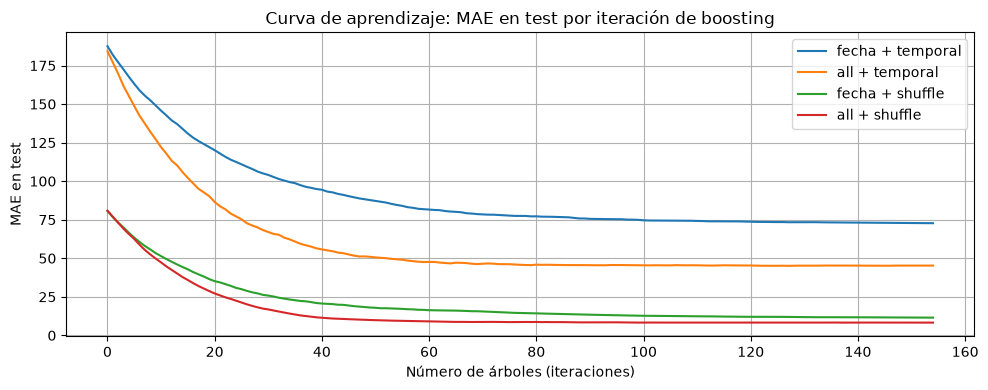

In [46]:
plt.figure(figsize=(10, 4))
for nombre, errores in curvas_error.items():
    plt.plot(errores, label=nombre)
plt.title("Curva de aprendizaje: MAE en test por iteración de boosting")
plt.xlabel("Número de árboles (iteraciones)")
plt.ylabel("MAE en test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Parte 5) Métricas (MAE, RMSE, MAPE, MASE)**

- _Clase 2, "Ejercicio Baselines Modernos" — sección E) Métricas (mismas funciones, con m=12: el naive estacional de lag 12, "el mismo mes del año anterior")._
- _Clase 2, "Baselines Modernos" — tabla comparativa de métricas con pd.DataFrame._ 
- _Clase 2, "Baselines Modernos" — sección D) Visualización de resultados._

In [47]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mase(y_true, y_pred, y_train_cron, m=12):
    # escala = MAE del naive estacional dentro del train (variación año a año)
    escala = np.mean(np.abs(y_train_cron[m:] - y_train_cron[:-m]))
    return mae(y_true, y_pred) / escala

In [48]:
# Su train no es cronológico, así que para la escala del MASE lo reordenamos por fecha (el "año anterior" solo tiene sentido en orden temporal).
filas = []
for nombre, pred in predicciones.items():
    tr, te, feats = experimentos[nombre]
    y_tr_cron = tr.sort_index()["y"].to_numpy()  # orden cronológico para la escala
    y_te = te["y"].to_numpy()
    filas.append({
        "Modelo": nombre,
        "MAE": mae(y_te, pred),
        "RMSE": rmse(y_te, pred),
        "MAPE": mape(y_te, pred),
        "MASE (m=12)": mase(y_te, pred, y_tr_cron, m=12),
    })

tabla = pd.DataFrame(filas).set_index("Modelo").round(3)
print(tabla.to_string())

                     MAE    RMSE    MAPE  MASE (m=12)
Modelo                                               
fecha + temporal  72.746  79.045  15.817        2.383
all + temporal    45.247  56.562   9.368        1.482
fecha + shuffle   11.493  15.235   4.930        0.197
all + shuffle      8.262  10.057   3.871        0.141


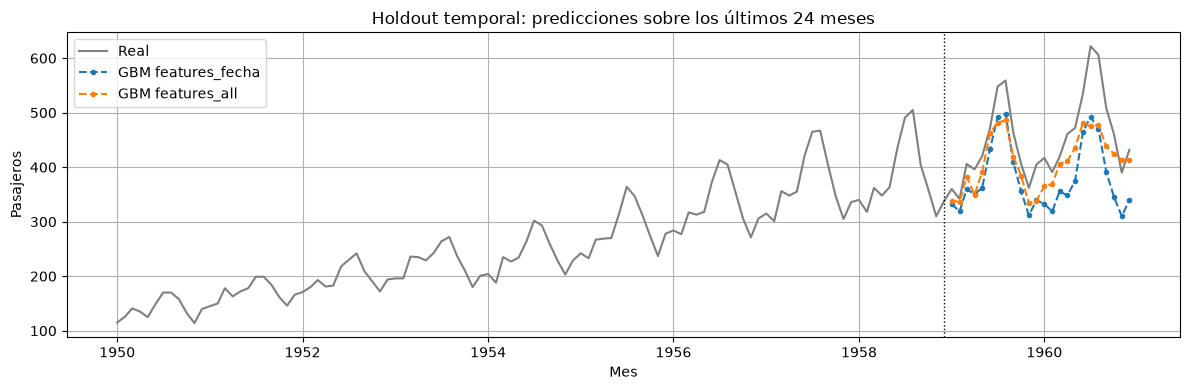

In [ ]:
# Solo el holdout temporal se puede graficar como forecast (el shuffle no es un futuro contiguo).
plt.figure(figsize=(12, 4))
plt.plot(df_model.index, df_model["y"], color="gray", label="Real")
plt.plot(test_t.index, predicciones["fecha + temporal"], ls="--", marker=".", label="GBM features_fecha")
plt.plot(test_t.index, predicciones["all + temporal"], ls="--", marker=".", label="GBM features_all")
plt.axvline(train_t.index[-1], color="k", ls=":", lw=1)  # separa train vs test
plt.title("Holdout temporal: predicciones sobre los últimos 24 meses")
plt.xlabel("Mes")
plt.ylabel("Pasajeros")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Parte 6) Interpretabilidad**

Modelo analizado: features_all + holdout temporal (el válido; el de shuffle tiene leakage).

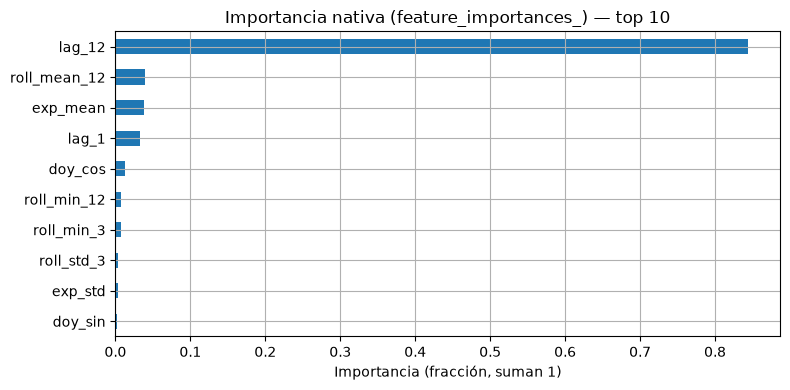

In [50]:
modelo_ref = modelos["all + temporal"]

# Importancia nativa del GBM: cuánto contribuyó cada feature a las divisiones de los árboles.
imp_nativa = pd.Series(modelo_ref.feature_importances_, index=features_all)
top10_nativa = imp_nativa.nlargest(10)

plt.figure(figsize=(8, 4))
top10_nativa.sort_values().plot.barh()
plt.title("Importancia nativa (feature_importances_) — top 10")
plt.xlabel("Importancia (fracción, suman 1)")
plt.grid(True)
plt.tight_layout()
plt.show()

Permutation importance: mide cuánto empeora el MAE de TEST al mezclar al azar cada feature, n_repeats=30 veces.

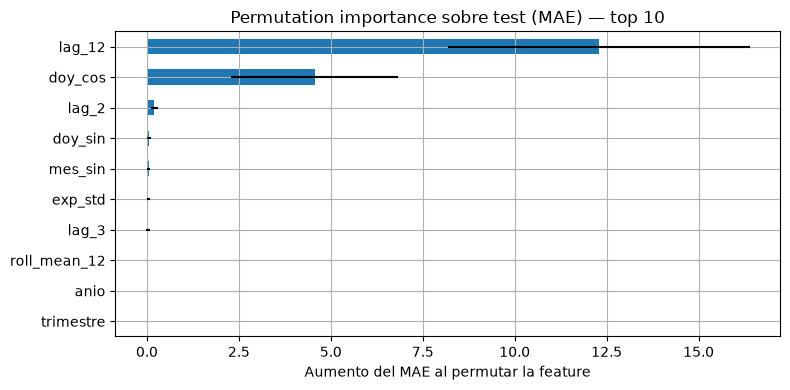

In [ ]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(modelo_ref, test_t[features_all], test_t["y"], scoring="neg_mean_absolute_error", n_repeats=30, random_state=42)
imp_perm = pd.Series(pi.importances_mean, index=features_all)
imp_perm_std = pd.Series(pi.importances_std, index=features_all)
top10_perm = imp_perm.nlargest(10)

plt.figure(figsize=(8, 4))
top10_perm.sort_values().plot.barh(xerr=imp_perm_std.reindex(top10_perm.sort_values().index))
plt.title("Permutation importance sobre test (MAE) — top 10")
plt.xlabel("Aumento del MAE al permutar la feature")
plt.grid(True)
plt.tight_layout()
plt.show()

Comparación de ambos rankings (top 10 según permutation importance).

In [52]:
comparacion = pd.DataFrame({
    "rank_nativa": imp_nativa.rank(ascending=False).astype(int),
    "rank_permutation": imp_perm.rank(ascending=False).astype(int),
    "imp_nativa": imp_nativa.round(4),
    "imp_permutation (ΔMAE)": imp_perm.round(2),
}).sort_values("rank_permutation").head(10)

print(comparacion.to_string())

             rank_nativa  rank_permutation  imp_nativa  imp_permutation (ΔMAE)
lag_12                 1                 1      0.8444                   12.29
doy_cos                5                 2      0.0132                    4.56
lag_2                 15                 3      0.0009                    0.20
doy_sin               10                 4      0.0016                    0.06
mes_sin               21                 5      0.0001                    0.05
exp_std                9                 6      0.0030                    0.04
lag_3                 19                 7      0.0005                    0.03
anio                  12                10      0.0014                    0.00
roll_max_12           11                10      0.0015                    0.00
roll_min_12            6                10      0.0075                    0.00


### **Parte 7) Preguntas de análisis**

**1) ¿Cuál de los dos holdouts refleja mejor el escenario real de uso del modelo?**

El **holdout temporal**. En producción el modelo siempre predice el futuro usando solo el pasado, y el holdout temporal reproduce exactamente esa situación: train = 1950–1958, test = 1959–1960. El holdout con shuffle mete filas futuras en el train (la verificación de la Parte 3 lo muestra: `max(train)=1960-12 > min(test)=1950-05`), y el efecto es dramático: el MASE baja de **1.51 a 0.14** con `features_all`. Esa mejora es ilusoria y viene del leakage a través de "el qué pasó": los lags y rolling de una fila de test están construidos con valores vecinos que quedaron en train, así que el modelo "ve" casi el valor que debe predecir. Las features de "el cuándo" (calendario) no filtran valores, pero el shuffle también las beneficia porque el modelo interpola entre años que ya vio en train en lugar de extrapolar hacia años nuevos.

**2) En el holdout temporal, ¿cuánto aporta features_all frente a features_fecha?**

Aporta una mejora importante: el MAE baja de **72.1 a 46.1** (−36%) y el MASE de **2.36 a 1.51**. Tiene sentido: las features de calendario solas le dicen al modelo "qué mes es", pero un GBM basado en árboles no puede extrapolar el nivel creciente de la serie más allá del rango visto en train (predice como mucho valores parecidos a los de 1958). Los lags y rolling le inyectan el **nivel reciente** de la serie, que es justo lo que el calendario no puede dar. Aun así, ni con `features_all` alcanza para ganarle al baseline.

**3) Interpretación del MASE en el holdout temporal**

Con `features_all` el MASE es **1.51 > 1**: el modelo **pierde** contra el naive estacional de lag 12 ("repetir el mismo mes del año anterior"). Con solo calendario pierde por más del doble (2.36). La lección es la de Clase 2, "Baselines Modernos": en series **cortas** (aquí quedan 108 meses de train tras el dropna) y **muy estacionales con tendencia sostenida**, el naive estacional es un baseline fuerte — captura a bajo costo toda la estacionalidad, y la parte que no captura (el crecimiento año a año) es justamente la que un modelo de árboles no sabe extrapolar fuera del rango de train. Un MASE > 1 no significa que el pipeline esté mal hecho: significa que la complejidad extra del GBM no se paga en este problema, y por eso siempre hay que reportar los baselines.

**4) ¿Qué feature domina ambos rankings y por qué tiene sentido?**

**`lag_12`** domina largamente los dos rankings: concentra **0.84** de la importancia nativa (el segundo, `doy_cos`, tiene 0.013) y es lejos la que más aumenta el MAE al permutarla (**+11.9**, contra +4.4 del segundo). Tiene todo el sentido: en una serie mensual con estacionalidad anual tan marcada como AirPassengers, `lag_12` es literalmente "el mismo mes del año anterior", o sea la versión-feature del naive estacional que ya vimos que es el mejor predictor individual. El modelo, en la práctica, aprende a tomar el valor del año pasado y ajustarlo levemente con el resto de las features. Ambas técnicas coinciden en el podio (`lag_12`, luego las cíclicas `doy_cos`/`doy_sin`), aunque el orden del resto difiere: la importancia nativa reparte crédito entre features correlacionadas (p. ej. `roll_min_12`) que la permutación revela como poco imprescindibles, porque al permutar una el modelo se apoya en las otras.
